# 02 · Retrieval-Augmented Generation (RAG)

**Lecture slides 21–37.** An LLM's knowledge is frozen at its pre-training data, its context window is limited, it gets distracted by irrelevant text, and you pay per token. RAG addresses all four: **retrieve** only the relevant pieces of a knowledge base, **augment** the prompt with them, then **generate**.

## Step 1 · Candidate retrieval — lexical vs. vector search

"Search the knowledge base" can mean two quite different things:

- **Lexical search** (a.k.a. keyword search) ranks documents by *term overlap* with the query — the classic algorithm is **BM25**: a smarter version of TF-IDF that rewards documents containing the query's exact words, weighted by how rare those words are across the corpus. Fast, needs no model, and excellent for exact names, codes, or jargon — but blind to paraphrase: a query about a "pet that can talk like a person" will not lexically match a document that says a bird "mimics human speech" if the words themselves don't overlap.
- **Vector search** (a.k.a. semantic/embedding search) instead encodes the query and every document as a dense vector using an embedding model, then ranks by *vector similarity* (cosine similarity). Because the embedding captures meaning rather than exact words, it *can* match "talk like a person" to "mimics human speech" — but it can be fooled by topical-but-irrelevant text, and it needs an embedding model to run.

In production RAG systems, neither wins outright, so most combine both: a **hybrid search** that fuses a lexical ranking and a vector ranking into one. Below we build both retrievers from a tiny knowledge base, compare them head-to-head on queries designed to favor one or the other, fuse them with **Reciprocal Rank Fusion (RRF)**, measure retrieval quality with standard ranking metrics, and finally run the full retrieve → augment → generate pipeline with a local LLM. (In notebook 04 the same retriever becomes a *tool* an agent decides when to call.)

This section needs a **local embedding model**: [`sentence-transformers/all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2) from Hugging Face, one of the smallest widely-used sentence embedding models (~90MB, 384-dim vectors). It downloads automatically the first time it's used and runs entirely offline afterward — no server to start. The generation step at the end uses `gemma4:e2b-mlx` through Ollama.

We load it with the plain `transformers` library (`AutoTokenizer` + `AutoModel`, with mean pooling done by hand) rather than the `sentence-transformers` wrapper package. That wrapper's recent releases hard-import an optional audio/video decoding dependency (`torchcodec`) at load time — even though we only need text — and `torchcodec` requires a matching FFmpeg install that not every machine has. Mean-pooling the token embeddings ourselves is exactly what that wrapper does internally, so results are equivalent, without the extra system dependency.

In [1]:
# %pip install -q rank_bm25 numpy transformers torch matplotlib ollama

## Prerequisite · Build the knowledge base: chunking

Real documents are too long to embed or stuff into a prompt whole, so they are split into **chunks** first. The key hyperparameters are the **chunk size** and the **overlap** between consecutive chunks (so a fact that straddles a boundary still appears intact in one chunk), plus the embedding size of the model you index them with.

In [2]:
from typing import Callable, Dict, List, Tuple

TEDDY_HISTORY = (
    "The teddy bear is named after Theodore Roosevelt, the 26th president of the United States. "
    "In 1902, on a hunting trip in Mississippi, Roosevelt refused to shoot a bear that had been tied to a tree. "
    "A political cartoon by Clifford Berryman made the story famous. "
    "Inspired by the cartoon, Brooklyn shop owner Morris Michtom created a stuffed toy bear and called it Teddy's bear. "
    "Around the same time in Germany, Richard Steiff designed a jointed toy bear for the Steiff company, "
    "and it became a hit at the Leipzig toy fair in 1903."
)


def chunk_text(text: str, chunk_size: int = 30, overlap: int = 10) -> List[str]:
    """Split text into chunks of `chunk_size` words, each sharing `overlap` words with the previous one."""
    words = text.split()
    step = chunk_size - overlap
    return [" ".join(words[start:start + chunk_size]) for start in range(0, max(len(words) - overlap, 1), step)]


for i, chunk in enumerate(chunk_text(TEDDY_HISTORY), start=1):
    print(f"chunk {i}: {chunk}\n")

chunk 1: The teddy bear is named after Theodore Roosevelt, the 26th president of the United States. In 1902, on a hunting trip in Mississippi, Roosevelt refused to shoot a bear that

chunk 2: trip in Mississippi, Roosevelt refused to shoot a bear that had been tied to a tree. A political cartoon by Clifford Berryman made the story famous. Inspired by the cartoon,

chunk 3: Clifford Berryman made the story famous. Inspired by the cartoon, Brooklyn shop owner Morris Michtom created a stuffed toy bear and called it Teddy's bear. Around the same time in

chunk 4: and called it Teddy's bear. Around the same time in Germany, Richard Steiff designed a jointed toy bear for the Steiff company, and it became a hit at the Leipzig

chunk 5: Steiff company, and it became a hit at the Leipzig toy fair in 1903.



**Try it:** change `chunk_size` and `overlap`. Too small and chunks lose context; too large and each chunk mixes several topics (and costs more tokens in the prompt).

To keep the retrieval comparison easy to read, the rest of this notebook uses a knowledge base that is already chunk-sized: one sentence per document.

## A tiny knowledge base

Eight short documents about pets. Two queries later on are deliberately chosen so that one favors lexical search (shares exact vocabulary with a document) and the other favors vector search (paraphrases a document without sharing its key words).

In [3]:
# ── The knowledge base RAG will retrieve from ─────────────────────────────────
CORPUS: List[Dict[str, str]] = [
    {"id": "d1", "text": "The Siberian Husky is a medium-sized working dog breed originally bred for sled pulling in cold climates."},
    {"id": "d2", "text": "Persian cats have long, thick fur and a calm, gentle temperament, making them popular indoor pets."},
    {"id": "d3", "text": "Goldfish are freshwater fish commonly kept in home aquariums; they can live over 10 years with proper care."},
    {"id": "d4", "text": "African Grey Parrots are known for their exceptional ability to mimic human speech and solve problems."},
    {"id": "d5", "text": "Bengal cats are a hybrid breed resulting from crossing domestic cats with the Asian leopard cat."},
    {"id": "d6", "text": "Golden Retrievers are friendly, intelligent dogs often used as guide dogs and family companions."},
    {"id": "d7", "text": "Bearded dragons are docile reptiles native to Australia, popular as low-maintenance terrarium pets."},
    {"id": "d8", "text": "Canaries are small songbirds prized for their bright colors and melodic singing ability."},
]
CORPUS_BY_ID: Dict[str, str] = {doc["id"]: doc["text"] for doc in CORPUS}

# One query that shares vocabulary with a document (favors lexical search)...
LEXICAL_FRIENDLY_QUERY = "Bengal cat leopard hybrid breed"
# ...and one that paraphrases a document without sharing its key words (favors vector search)
SEMANTIC_FRIENDLY_QUERY = "a pet that can talk like a person"

for doc in CORPUS:
    print(f"{doc['id']}: {doc['text']}")

d1: The Siberian Husky is a medium-sized working dog breed originally bred for sled pulling in cold climates.
d2: Persian cats have long, thick fur and a calm, gentle temperament, making them popular indoor pets.
d3: Goldfish are freshwater fish commonly kept in home aquariums; they can live over 10 years with proper care.
d4: African Grey Parrots are known for their exceptional ability to mimic human speech and solve problems.
d5: Bengal cats are a hybrid breed resulting from crossing domestic cats with the Asian leopard cat.
d6: Golden Retrievers are friendly, intelligent dogs often used as guide dogs and family companions.
d7: Bearded dragons are docile reptiles native to Australia, popular as low-maintenance terrarium pets.
d8: Canaries are small songbirds prized for their bright colors and melodic singing ability.


## Lexical search (BM25)

`rank_bm25` implements the algorithm directly: tokenize every document, build a frequency index, then score a query by how much of its (rare, informative) vocabulary each document contains.

In [4]:
# ── Lexical retriever: BM25 over whitespace/punctuation-tokenized text ────────
import re

from rank_bm25 import BM25Okapi


def _tokenize(text: str) -> List[str]:
    return re.findall(r"[a-z0-9]+", text.lower())


BM25_CORPUS_TOKENS = [_tokenize(doc["text"]) for doc in CORPUS]
bm25_index = BM25Okapi(BM25_CORPUS_TOKENS)


def lexical_search(query: str, top_k: int = len(CORPUS)) -> List[Tuple[str, float]]:
    """Rank every doc_id by BM25 score against `query`; returns (doc_id, score) sorted best-first."""
    scores = bm25_index.get_scores(_tokenize(query))
    ranked = sorted(zip((doc["id"] for doc in CORPUS), scores), key=lambda x: x[1], reverse=True)
    return ranked[:top_k]


for label, query in [("lexical-friendly", LEXICAL_FRIENDLY_QUERY), ("semantic-friendly", SEMANTIC_FRIENDLY_QUERY)]:
    print(f"Query ({label}): {query!r}")
    for doc_id, score in lexical_search(query, top_k=3):
        print(f"  {doc_id}  score={score:.3f}  {CORPUS_BY_ID[doc_id]}")
    print()

Query (lexical-friendly): 'Bengal cat leopard hybrid breed'
  d5  score=7.314  Bengal cats are a hybrid breed resulting from crossing domestic cats with the Asian leopard cat.
  d1  score=0.894  The Siberian Husky is a medium-sized working dog breed originally bred for sled pulling in cold climates.
  d2  score=0.000  Persian cats have long, thick fur and a calm, gentle temperament, making them popular indoor pets.

Query (semantic-friendly): 'a pet that can talk like a person'
  d3  score=1.506  Goldfish are freshwater fish commonly kept in home aquariums; they can live over 10 years with proper care.
  d2  score=0.894  Persian cats have long, thick fur and a calm, gentle temperament, making them popular indoor pets.
  d5  score=0.894  Bengal cats are a hybrid breed resulting from crossing domestic cats with the Asian leopard cat.



## Vector search (embeddings)

Every document is embedded once (cached in `CORPUS_EMBEDDINGS`) with a small local Hugging Face model; a query is embedded on the fly and ranked against the corpus by cosine similarity. Embeddings come from mean-pooling the model's per-token outputs — the standard way to turn a transformer's token-level output into one fixed-size vector per sentence.

In [5]:
# ── Vector retriever: local Hugging Face embeddings + cosine similarity ───────
import numpy as np
import torch
from transformers import AutoModel, AutoTokenizer

EMBED_MODEL_ID = "sentence-transformers/all-MiniLM-L6-v2"
embed_tokenizer = AutoTokenizer.from_pretrained(EMBED_MODEL_ID)
embed_model = AutoModel.from_pretrained(EMBED_MODEL_ID)
embed_model.eval()


def embed_texts(texts: List[str]) -> np.ndarray:
    """Mean-pool token embeddings (masking out padding) into one L2-normalized vector per text."""
    encoded = embed_tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
    with torch.no_grad():
        token_embeddings = embed_model(**encoded)[0]
    mask = encoded["attention_mask"].unsqueeze(-1).float()
    pooled = (token_embeddings * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
    return torch.nn.functional.normalize(pooled, p=2, dim=1).numpy()


def _cosine_similarity(query_vec: np.ndarray, doc_vecs: np.ndarray) -> np.ndarray:
    # embed_texts already L2-normalizes, so the dot product IS the cosine similarity
    return doc_vecs @ query_vec


# Embed the whole corpus once and reuse it for every query below
CORPUS_EMBEDDINGS = embed_texts([doc["text"] for doc in CORPUS])


def vector_search(query: str, top_k: int = len(CORPUS)) -> List[Tuple[str, float]]:
    """Rank every doc_id by cosine similarity between its embedding and the query's; returns (doc_id, score) sorted best-first."""
    query_vec = embed_texts([query])[0]
    similarities = _cosine_similarity(query_vec, CORPUS_EMBEDDINGS)
    ranked = sorted(zip((doc["id"] for doc in CORPUS), similarities), key=lambda x: x[1], reverse=True)
    return ranked[:top_k]


for label, query in [("lexical-friendly", LEXICAL_FRIENDLY_QUERY), ("semantic-friendly", SEMANTIC_FRIENDLY_QUERY)]:
    print(f"Query ({label}): {query!r}")
    for doc_id, score in vector_search(query, top_k=3):
        print(f"  {doc_id}  score={score:.3f}  {CORPUS_BY_ID[doc_id]}")
    print()

/Users/rinabuoy/miniforge3/envs/LLMs/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7801.31it/s]

Query (lexical-friendly): 'Bengal cat leopard hybrid breed'
  d5  score=0.794  Bengal cats are a hybrid breed resulting from crossing domestic cats with the Asian leopard cat.
  d2  score=0.363  Persian cats have long, thick fur and a calm, gentle temperament, making them popular indoor pets.
  d1  score=0.267  The Siberian Husky is a medium-sized working dog breed originally bred for sled pulling in cold climates.

Query (semantic-friendly): 'a pet that can talk like a person'
  d2  score=0.387  Persian cats have long, thick fur and a calm, gentle temperament, making them popular indoor pets.
  d4  score=0.330  African Grey Parrots are known for their exceptional ability to mimic human speech and solve problems.
  d6  score=0.319  Golden Retrievers are friendly, intelligent dogs often used as guide dogs and family companions.



## Combining both: hybrid search via Reciprocal Rank Fusion

BM25 scores and cosine similarities live on different, incomparable scales, so averaging them directly is meaningless. **Reciprocal Rank Fusion (RRF)** sidesteps that: it only looks at each result's *rank* (1st, 2nd, 3rd...) in each ranking, not its raw score, and sums `1 / (k + rank)` across all rankings a document appears in — a common constant `k` (60 here) discounts the effect of any single retriever placing something 1st vs 2nd. A document that ranks reasonably well on *both* retrievers beats one that ranks 1st on one but doesn't appear on the other.

In [6]:
# ── Hybrid retriever: fuse the lexical and vector rankings with RRF ───────────
def reciprocal_rank_fusion(rankings: List[List[str]], k: int = 60) -> List[Tuple[str, float]]:
    """Fuse several ranked doc_id lists into one, scoring by 1/(k + rank) summed across rankings."""
    fused_scores: Dict[str, float] = {}
    for ranking in rankings:
        for rank, doc_id in enumerate(ranking, start=1):
            fused_scores[doc_id] = fused_scores.get(doc_id, 0.0) + 1.0 / (k + rank)
    return sorted(fused_scores.items(), key=lambda x: x[1], reverse=True)


def hybrid_search(query: str, top_k: int = 3) -> List[Tuple[str, float]]:
    """Rank doc_ids by RRF-fused lexical (BM25) + vector (embedding) rankings."""
    lexical_ranking = [doc_id for doc_id, _ in lexical_search(query)]
    vector_ranking = [doc_id for doc_id, _ in vector_search(query)]
    fused = reciprocal_rank_fusion([lexical_ranking, vector_ranking])
    return fused[:top_k]


for label, query in [("lexical-friendly", LEXICAL_FRIENDLY_QUERY), ("semantic-friendly", SEMANTIC_FRIENDLY_QUERY)]:
    print(f"Query ({label}): {query!r}")
    for doc_id, score in hybrid_search(query, top_k=3):
        print(f"  {doc_id}  rrf_score={score:.4f}  {CORPUS_BY_ID[doc_id]}")
    print()

Query (lexical-friendly): 'Bengal cat leopard hybrid breed'
  d5  rrf_score=0.0328  Bengal cats are a hybrid breed resulting from crossing domestic cats with the Asian leopard cat.
  d1  rrf_score=0.0320  The Siberian Husky is a medium-sized working dog breed originally bred for sled pulling in cold climates.
  d2  rrf_score=0.0320  Persian cats have long, thick fur and a calm, gentle temperament, making them popular indoor pets.

Query (semantic-friendly): 'a pet that can talk like a person'
  d2  rrf_score=0.0325  Persian cats have long, thick fur and a calm, gentle temperament, making them popular indoor pets.
  d4  rrf_score=0.0315  African Grey Parrots are known for their exceptional ability to mimic human speech and solve problems.
  d3  rrf_score=0.0311  Goldfish are freshwater fish commonly kept in home aquariums; they can live over 10 years with proper care.



## Seeing it: lexical vs. vector vs. hybrid, side by side

Numbers in a printout are hard to compare at a glance. The chart below normalizes each method's scores to a shared 0–1 scale (min→max *within that method*, since BM25 scores, cosine similarities, and RRF scores live on incomparable raw scales) and plots all eight documents for both demo queries. Watch `d5*` (Bengal cat) dominate every method on the left — an exact vocabulary match — while `d4*` (the parrot) scores exactly **zero** under lexical search on the right, yet is clearly present once vector and hybrid search are in play.

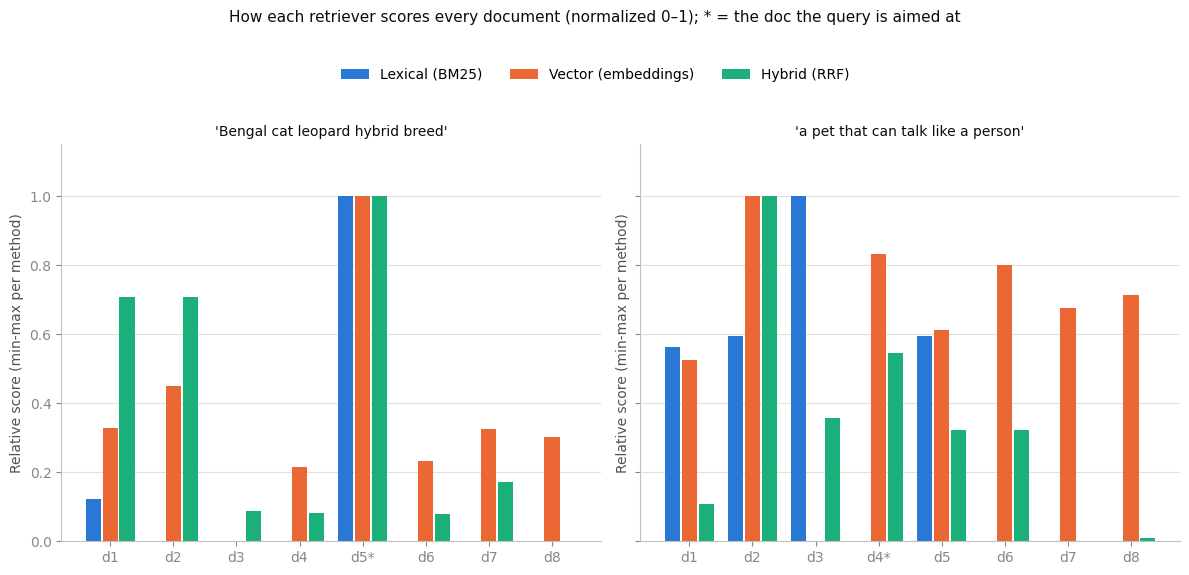

In [7]:
# ── Visualize how the three retrievers score every document ──────────────────
import matplotlib.pyplot as plt

# Fixed categorical colors — one per method, same color in both panels (identity, not rank)
METHOD_COLORS = {"Lexical (BM25)": "#2a78d6", "Vector (embeddings)": "#eb6834", "Hybrid (RRF)": "#1baf7a"}
DOC_IDS = [doc["id"] for doc in CORPUS]


def _normalize(scores: Dict[str, float]) -> np.ndarray:
    """Min-max scale one method's scores to [0, 1] so different raw scales become comparable."""
    values = np.array([scores.get(doc_id, 0.0) for doc_id in DOC_IDS], dtype=float)
    lo, hi = values.min(), values.max()
    return (values - lo) / (hi - lo) if hi > lo else values


def plot_retrieval_comparison(query: str, target_doc_id: str, ax: plt.Axes) -> None:
    method_scores = {
        "Lexical (BM25)": dict(lexical_search(query)),
        "Vector (embeddings)": dict(vector_search(query)),
        "Hybrid (RRF)": dict(hybrid_search(query, top_k=len(CORPUS))),
    }
    n_methods = len(method_scores)
    bar_width = 0.8 / n_methods
    x = np.arange(len(DOC_IDS))

    for i, (method, scores) in enumerate(method_scores.items()):
        offset = (i - (n_methods - 1) / 2) * bar_width
        ax.bar(x + offset, _normalize(scores), width=bar_width * 0.9, color=METHOD_COLORS[method], label=method)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{d}*" if d == target_doc_id else d for d in DOC_IDS], color="#52514e")
    ax.set_ylim(0, 1.15)
    ax.set_title(f"{query!r}", fontsize=10, color="#0b0b0b")
    ax.set_ylabel("Relative score (min-max per method)", color="#52514e")
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color("#c3c2b7")
    ax.tick_params(colors="#898781")


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
plot_retrieval_comparison(LEXICAL_FRIENDLY_QUERY, "d5", axes[0])
plot_retrieval_comparison(SEMANTIC_FRIENDLY_QUERY, "d4", axes[1])
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.05))
fig.suptitle("How each retriever scores every document (normalized 0–1); * = the doc the query is aimed at", y=1.14, fontsize=11, color="#0b0b0b")
fig.tight_layout()
plt.show()

## Step 2 · Ranking, and quantifying retrieval performance

Retrieval usually has two stages: **candidate retrieval** (cheap, over the whole knowledge base, tuned for *recall*) then **ranking** (a more expensive scorer over the few candidates, tuned for *precision*). To know whether a retriever is any good, we need a small set of test queries with known relevant documents, and ranking metrics:

| Metric | Question it answers |
|---|---|
| **Precision@k** | Of the top *k* results, what fraction are relevant? |
| **RR@k** (reciprocal rank) | 1 / rank of the *first* relevant result (0 if none in the top *k*). Averaged over queries → **MRR**. |
| **NDCG@k** | Are the *most* relevant documents near the top? Rewards graded relevance, discounted by log of the rank, normalized so a perfect ranking = 1. |

In [8]:
import math

# Test queries with graded relevance labels: {doc_id: relevance} (2 = highly relevant, 1 = partially)
EVAL_SET: List[Tuple[str, Dict[str, int]]] = [
    ("Bengal cat leopard hybrid breed", {"d5": 2}),
    ("a pet that can talk like a person", {"d4": 2}),
    ("which dog breed pulls sleds in the snow?", {"d1": 2}),
    ("a fluffy indoor cat with a relaxed personality", {"d2": 2}),
    ("an easy pet that lives in a glass tank", {"d7": 2, "d3": 1}),
    ("which birds make good pets?", {"d4": 2, "d8": 2}),
    ("dogs that help blind people", {"d6": 2}),
    ("cat breeds", {"d2": 2, "d5": 2}),
]


def precision_at_k(ranked: List[str], relevant: Dict[str, int], k: int) -> float:
    return sum(doc_id in relevant for doc_id in ranked[:k]) / k


def reciprocal_rank_at_k(ranked: List[str], relevant: Dict[str, int], k: int) -> float:
    for rank, doc_id in enumerate(ranked[:k], start=1):
        if doc_id in relevant:
            return 1.0 / rank
    return 0.0


def ndcg_at_k(ranked: List[str], relevant: Dict[str, int], k: int) -> float:
    dcg = sum(relevant.get(doc_id, 0) / math.log2(rank + 1) for rank, doc_id in enumerate(ranked[:k], start=1))
    ideal = sorted(relevant.values(), reverse=True)[:k]
    idcg = sum(rel / math.log2(rank + 1) for rank, rel in enumerate(ideal, start=1))
    return dcg / idcg if idcg > 0 else 0.0


RETRIEVERS: Dict[str, Callable[[str], List[Tuple[str, float]]]] = {
    "Lexical (BM25)": lexical_search,
    "Vector (embeddings)": vector_search,
    "Hybrid (RRF)": lambda q: hybrid_search(q, top_k=len(CORPUS)),
}

K = 3
print(f"{'Retriever':22} {'P@' + str(K):>7} {'MRR@' + str(K):>7} {'NDCG@' + str(K):>8}")
for name, search in RETRIEVERS.items():
    scores = {"p": [], "rr": [], "ndcg": []}
    for query, relevant in EVAL_SET:
        ranked = [doc_id for doc_id, _ in search(query)]
        scores["p"].append(precision_at_k(ranked, relevant, K))
        scores["rr"].append(reciprocal_rank_at_k(ranked, relevant, K))
        scores["ndcg"].append(ndcg_at_k(ranked, relevant, K))
    mean = {m: sum(v) / len(v) for m, v in scores.items()}
    print(f"{name:22} {mean['p']:7.3f} {mean['rr']:7.3f} {mean['ndcg']:8.3f}")

Retriever                  P@3   MRR@3   NDCG@3
Lexical (BM25)           0.292   0.625    0.599
Vector (embeddings)      0.458   0.875    0.913
Hybrid (RRF)             0.375   0.729    0.726


Two things to notice:

- On *this* query set, which is mostly paraphrases, vector search wins and hybrid lands in between: RRF gives BM25's (poor) ranking equal weight. On jargon-heavy queries (product codes, names) the picture flips. That is exactly why you measure on queries that look like your real users' queries instead of assuming hybrid is always best.
- P@3 can never reach 1.0 here: most queries have only one relevant document, so at most 1 of the top 3 can be relevant. That's why RR and NDCG are usually more informative on small labeled sets.

**Try it:** add your own queries to `EVAL_SET` — especially paraphrases with no shared words (hurts BM25) or exact rare names (hurts embeddings) — and watch the table change.

## Steps 2 & 3 · Augment the prompt, then generate

Now the full pipeline: retrieve the top chunks, paste them into the prompt with numbered markers, and ask the LLM to answer *only* from them. To make the point clearly we use a knowledge base the model **cannot** know from pre-training — the internal FAQ of a fictional shop.

In [9]:
import ollama

from rag_utils import HybridRetriever

LLM_MODEL_ID = "gemma4:e2b-mlx"  # any chat model you have pulled in Ollama works

# A fictional shop — none of this is in any model's training data
SHOP_FAQ: List[Dict[str, str]] = [
    {"id": "f1", "text": "Teddy's Toy Shop is open Tuesday to Sunday, 10:00 to 19:00. It is closed on Mondays."},
    {"id": "f2", "text": "Returns: any bear can be returned within 45 days of purchase. A receipt is required for a cash refund; without one we offer store credit."},
    {"id": "f3", "text": "The Honey Points loyalty program gives 1 point per dollar spent. 100 Honey Points can be redeemed for a free mini bear."},
    {"id": "f4", "text": "The Bear Hospital repairs torn seams and loose eyes for free on bears bought at our shop; other bears cost $8 per repair."},
    {"id": "f5", "text": "Gift wrapping is free during December and costs $3 the rest of the year."},
    {"id": "f6", "text": "Our best-selling bear is Captain Honeypaw, a 40 cm bear with a sailor hat, priced at $34."},
    {"id": "f7", "text": "Online orders ship within 2 business days. Shipping is free for orders over $50."},
    {"id": "f8", "text": "Build-a-Bear workshops for children run every Saturday at 14:00 and must be booked in advance."},
]
faq_retriever = HybridRetriever(SHOP_FAQ)

question = "Can I return a teddy bear after 30 days if I lost the receipt?"

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10887.98it/s]

In [10]:
# Without retrieval: the model can only guess
response = ollama.chat(model=LLM_MODEL_ID, messages=[{"role": "user", "content": question}])
print(response.message.content)

I am sorry, but I cannot give you a definitive answer because **I do not know which store or company you purchased the teddy bear from.**

Return policies vary widely from one retailer to another.

**To find out if you can return the teddy bear without a receipt, you need to check the specific return policy of the store where you bought it.**

Here is what you should do:

1. **Check the Store's Website:** Look for their "Returns & Exchanges" policy.
2. **Contact Customer Service:** This is the fastest way to get a definitive answer. Call them or visit their customer service page and ask specifically about their policy for returns without a receipt.
3. **Look for Alternatives:** Sometimes stores allow returns if you can provide alternative proof of purchase, such as:
    * A credit card statement showing the purchase.
    * A loyalty card or membership number.
    * A digital receipt or email confirmation.

**In summary: Check your purchase receipt or contact the retailer directly. They

In [11]:
# 1. Retrieve
results = faq_retriever.hybrid_search(question, top_k=3)
context = "\n".join(f"[{i}] {faq_retriever.by_id[doc_id]}" for i, (doc_id, _) in enumerate(results, start=1))

# 2. Augment
augmented_prompt = (
    "Answer the question using ONLY the context below. Cite sources with their [n] markers. "
    "If the context does not contain the answer, say you don't know.\n\n"
    f"Context:\n{context}\n\nQuestion: {question}"
)
print(augmented_prompt)

Answer the question using ONLY the context below. Cite sources with their [n] markers. If the context does not contain the answer, say you don't know.

Context:
[1] Returns: any bear can be returned within 45 days of purchase. A receipt is required for a cash refund; without one we offer store credit.
[2] Teddy's Toy Shop is open Tuesday to Sunday, 10:00 to 19:00. It is closed on Mondays.
[3] The Honey Points loyalty program gives 1 point per dollar spent. 100 Honey Points can be redeemed for a free mini bear.

Question: Can I return a teddy bear after 30 days if I lost the receipt?


In [12]:
# 3. Generate
response = ollama.chat(model=LLM_MODEL_ID, messages=[{"role": "user", "content": augmented_prompt}])
print(response.message.content)
print(f"\n(prompt tokens: {response.prompt_eval_count})")

Yes, any bear can be returned within 45 days of purchase [1]. However, since a receipt is required for a cash refund, if you do not have one, you will be offered store credit [1].

(prompt tokens: 175)


Why not just paste the *whole* knowledge base into every prompt? For 8 sentences you could — but real knowledge bases have millions of chunks. Pricing is per token, context windows are finite, and irrelevant text distracts the model. Compare the prompt size:

In [13]:
everything = "\n".join(f"[{i}] {doc['text']}" for i, doc in enumerate(SHOP_FAQ, start=1))
response = ollama.chat(
    model=LLM_MODEL_ID,
    messages=[{"role": "user", "content": augmented_prompt.replace(context, everything)}],
)
print(f"prompt tokens with the whole knowledge base: {response.prompt_eval_count}")

prompt tokens with the whole knowledge base: 309


## Key takeaways

- RAG = **retrieve** relevant chunks → **augment** the prompt → **generate**. It gives the model knowledge it never saw in pre-training, with sources it can cite.
- The knowledge base is built by **chunking** documents (chunk size, overlap) and indexing them.
- **Lexical search** (BM25) matches exact words; **vector search** matches meaning; **hybrid** search with **RRF** fuses both by rank.
- Measure retrievers with **Precision@k**, **RR@k / MRR** and **NDCG@k** on a labeled query set before trusting them.